# Mortalidad Materna (UNICEF)

**Objetivo:**
- 3.1 Descripción de los datos
- 3.2 Limpieza y preparación
- 3.3 EDA (estadísticas, distribuciones, correlaciones, sesgos, viabilidad)

**Fuente:** UNICEF Data – Maternal Mortality (MMR).
**Unidad de análisis:** País–Año.

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
file_path = "MMR-maternal-deaths-and-LTR_MMEIG-trends_2000-2023_Revised-2025-1.xlsx"

df = pd.read_excel(file_path, sheet_name="MMR_country_level", header=3)
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28
0,ISO Code,Country,UNICEF Programme Region,UNICEF Reporting Region,UNICEF Sub-Reporting Region,2000,2001,2002,2003,2004,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,AFG,Afghanistan,South Asia,South Asia,South Asia,1372,1311,1263,1201,1166,...,755,741,702,659,629,601,634,660,551,521
2,ALB,Albania,Europe and Central Asia,Europe and Central Asia,Eastern Europe and Central Asia,15,14,14,13,13,...,10,9,8,8,7,7,7,14,8,7
3,DZA,Algeria,Middle East and North Africa,Middle East and North Africa,Middle East and North Africa,123,113,102,101,91,...,80,79,79,77,75,73,97,79,64,62
4,AND,Andorra,Industrialized,Europe and Central Asia,Western Europe,14,14,14,13,12,...,10,10,10,11,11,11,48,18,17,11


In [105]:
df.columns = df.iloc[0]

df = df[1:].reset_index(drop=True)

df.head()

,ISO Code,Country,UNICEF Programme Region,UNICEF Reporting Region,UNICEF Sub-Reporting Region,2000,2001,2002,2003,2004,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,AFG,Afghanistan,South Asia,South Asia,South Asia,1372,1311,1263,1201,1166,...,755,741,702,659,629,601,634,660,551,521
1,ALB,Albania,Europe and Central Asia,Europe and Central Asia,Eastern Europe and Central Asia,15,14,14,13,13,...,10,9,8,8,7,7,7,14,8,7
2,DZA,Algeria,Middle East and North Africa,Middle East and North Africa,Middle East and North Africa,123,113,102,101,91,...,80,79,79,77,75,73,97,79,64,62
3,AND,Andorra,Industrialized,Europe and Central Asia,Western Europe,14,14,14,13,12,...,10,10,10,11,11,11,48,18,17,11
4,AGO,Angola,Eastern and Southern Africa,Sub-Saharan Africa,Eastern and Southern Africa,659,629,602,538,499,...,262,249,236,220,208,202,195,211,185,183


In [106]:
df.columns = df.columns.astype(str).str.strip()

In [107]:
df = df.dropna(subset=["Country"])
df.shape

(195, 29)

In [108]:
year_cols = [c for c in df.columns if str(c).replace(".0","").isdigit()]
len(year_cols), year_cols[:3], year_cols[-3:]

(24, ['2000', '2001', '2002'], ['2021', '2022', '2023'])

In [109]:
id_vars = [c for c in [
    "ISO Code","Country",
    "UNICEF Programme Region","UNICEF Reporting Region","UNICEF Sub-Reporting Region"
] if c in df.columns]

df_long = df.melt(
    id_vars=id_vars,
    value_vars=year_cols,
    var_name="Year",
    value_name="MMR"
)

df_long["Year"] = df_long["Year"].astype(str).str.replace(".0","", regex=False).astype(int)
df_long.head()

,ISO Code,Country,UNICEF Programme Region,UNICEF Reporting Region,UNICEF Sub-Reporting Region,Year,MMR
0,AFG,Afghanistan,South Asia,South Asia,South Asia,2000,1372
1,ALB,Albania,Europe and Central Asia,Europe and Central Asia,Eastern Europe and Central Asia,2000,15
2,DZA,Algeria,Middle East and North Africa,Middle East and North Africa,Middle East and North Africa,2000,123
3,AND,Andorra,Industrialized,Europe and Central Asia,Western Europe,2000,14
4,AGO,Angola,Eastern and Southern Africa,Sub-Saharan Africa,Eastern and Southern Africa,2000,659


In [110]:
df_long.shape
df_long["MMR"].isna().mean()
df_long["MMR"].describe()

,MMR
count,4680.000000
mean,173.833974
std,254.497173
min,0.000000
25%,14.000000
50%,58.000000
75%,231.000000
max,1662.000000


## Análisis de Valores Faltantes

Se observa un bajo porcentaje de valores faltantes en la variable MMR.

No se realizó imputación en esta etapa del análisis exploratorio,
ya que imputar podría introducir sesgos estructurales en países con
limitaciones estadísticas o conflictos.

El impacto de los valores faltantes deberá considerarse en etapas posteriores
de modelado.

## 3.1 Descripción de los Datos

El dataset corresponde a estimaciones oficiales de la Razón de Mortalidad Materna (MMR)
publicadas por el grupo interagencial MMEIG (WHO, UNICEF, UNFPA, World Bank, UNDESA).

Unidad de análisis: País–Año  
Periodo analizado: 2000–2023  
Variable principal: MMR (muertes maternas por cada 100,000 nacidos vivos).

El dataset fue transformado de formato ancho (wide) a formato largo (long),
permitiendo analizar tendencias temporales y comparaciones regionales.

In [111]:
df_long["MMR"].describe()

,MMR
count,4680.000000
mean,173.833974
std,254.497173
min,0.000000
25%,14.000000
50%,58.000000
75%,231.000000
max,1662.000000


## Estadísticas Descriptivas

La distribución global de MMR presenta:

- Media superior a la mediana.
- Alta desviación estándar.
- Presencia de valores extremos (cola pesada).

Esto indica una distribución fuertemente asimétrica a la derecha,
lo que sugiere una alta desigualdad entre países.

La diferencia entre media y mediana confirma que un grupo reducido
de países presenta niveles extremadamente altos de mortalidad materna.

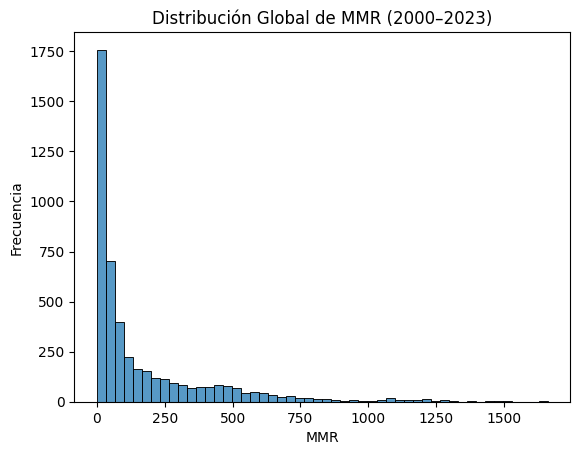

In [112]:
plt.figure()
sns.histplot(df_long["MMR"].dropna(), bins=50)
plt.title("Distribución Global de MMR (2000–2023)")
plt.xlabel("MMR")
plt.ylabel("Frecuencia")
plt.show()

## Distribución Global

El histograma muestra una clara asimetría positiva:

- La mayoría de los países presentan valores bajos o moderados.
- Un subconjunto reducido presenta valores extremadamente altos.

Esto confirma la existencia de desigualdades estructurales en salud materna
a nivel global.

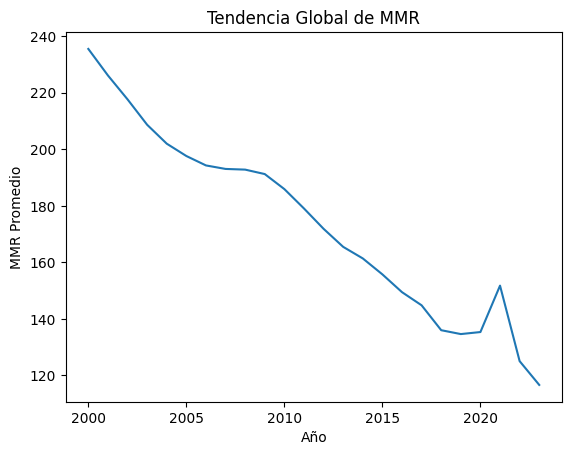

In [113]:
trend = df_long.groupby("Year")["MMR"].mean()

plt.figure()
plt.plot(trend.index, trend.values)
plt.title("Tendencia Global de MMR")
plt.xlabel("Año")
plt.ylabel("MMR Promedio")
plt.show()

## Tendencia Temporal

La tendencia global muestra una reducción progresiva de la MMR
entre 2000 y 2023.

Esto indica avances globales en salud materna, aunque la disminución
no es uniforme entre regiones.

La existencia de una tendencia clara sugiere que el fenómeno es dinámico
y potencialmente modelable.

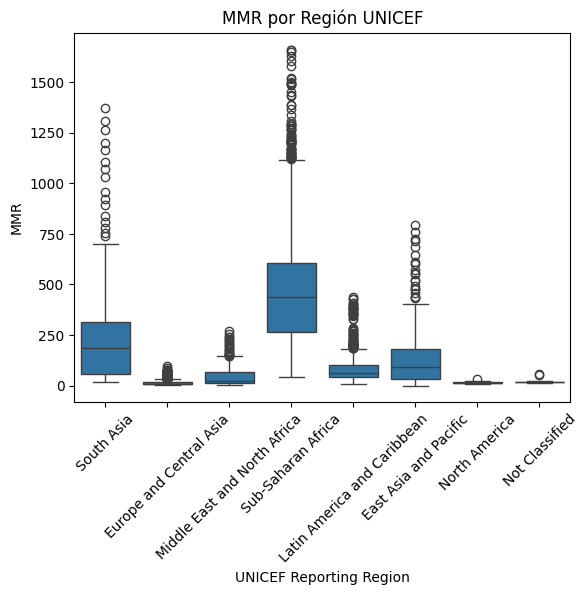

In [114]:
plt.figure()
sns.boxplot(
    data=df_long,
    x="UNICEF Reporting Region",
    y="MMR"
)
plt.xticks(rotation=45)
plt.title("MMR por Región UNICEF")
plt.show()

## Diferencias Regionales

El análisis por región evidencia diferencias estructurales significativas.

Algunas regiones presentan medianas considerablemente superiores,
así como mayor dispersión.

Esto sugiere que el contexto geográfico e institucional desempeña
un papel determinante en la mortalidad materna.

## Valores Extremos

Los percentiles altos (90, 95, 99) muestran que existen países
con niveles extremadamente elevados de MMR.

Estos valores no se consideran errores, sino reflejo de contextos
de fragilidad institucional, conflicto o debilidad del sistema sanitario.

La presencia de cola pesada sugiere que podrían considerarse
transformaciones (por ejemplo, logarítmica) en etapas de modelado.

## Viabilidad Empírica del Problema

El análisis exploratorio demuestra que:

- Existe alta variabilidad en la MMR.
- Se observan tendencias temporales claras.
- Existen diferencias estructurales entre regiones.
- La distribución presenta señal estadística significativa.

Por lo tanto, el problema es cuantificable, estructurado y
empíricamente viable para la construcción de modelos predictivos.

La estructura panel País–Año permite plantear un problema de regresión supervisada con dimensión temporal.